# Exercise Week 9: Spectral Analysis

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima_process import ArmaProcess
from scipy import integrate, signal as sig
import statsmodels.api as sm
from pandas_datareader import data as web
from datetime import datetime
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

from data import get_periodic_process
from utils import get_figure, time_plot, acovf_plot, plot_fft, arma_theoretical_spectral_density, acf_plot


c:\Users\paeschu\source\repos\hslu\time\notebooks\data.py:12: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


---
# Part 1: Synthetic Periodic and Aperiodic Signals

In this section, we simulate various synthetic signals and analyze their properties in both time and frequency domains.

## 1.1 Pure Periodic Signal (Single Frequency)

Simple sinusoidal signal with a single frequency.

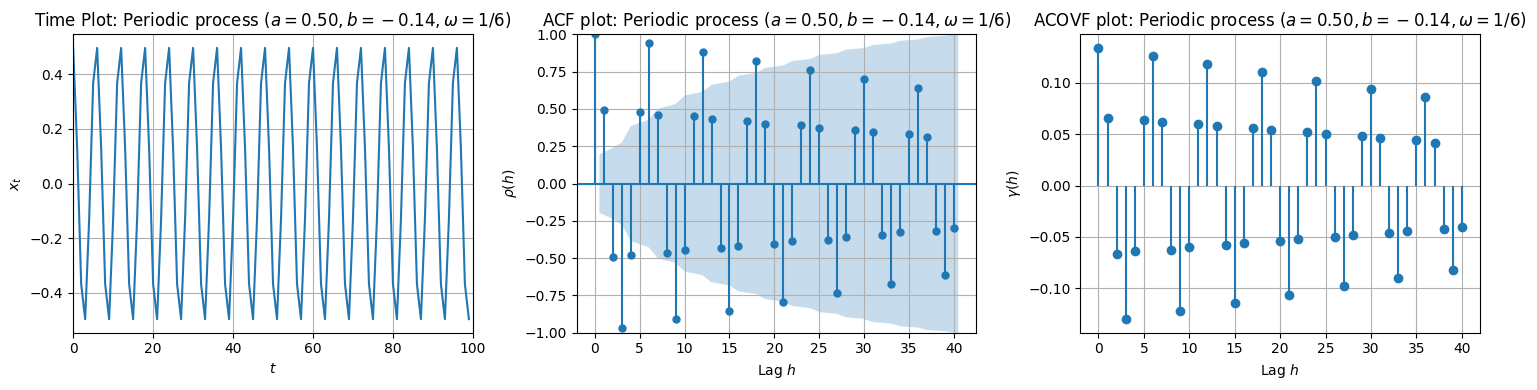

In [2]:
# Generate a pure sinusoidal signal with period 6
n = 100
x_t, x_name = get_periodic_process(seed=42, npoints=n, sd=1, period=6)

# Create plots: time series, ACF, and auto-covariance
fig, (ax1, ax2, ax3) = get_figure(ncols=3, figsize=(15, 4))

time_plot(
    np.arange(n),
    x_t,
    title=f"Time Plot: {x_name}",
    prefix_title=False,
    ax=ax1,
    xlim=(0, 100),
)

acf_plot(x_t, 40, ax=ax2, title=x_name, prefix_title=True)
acovf_plot(x_t, 40, title=x_name, ax=ax3)

fig.tight_layout()

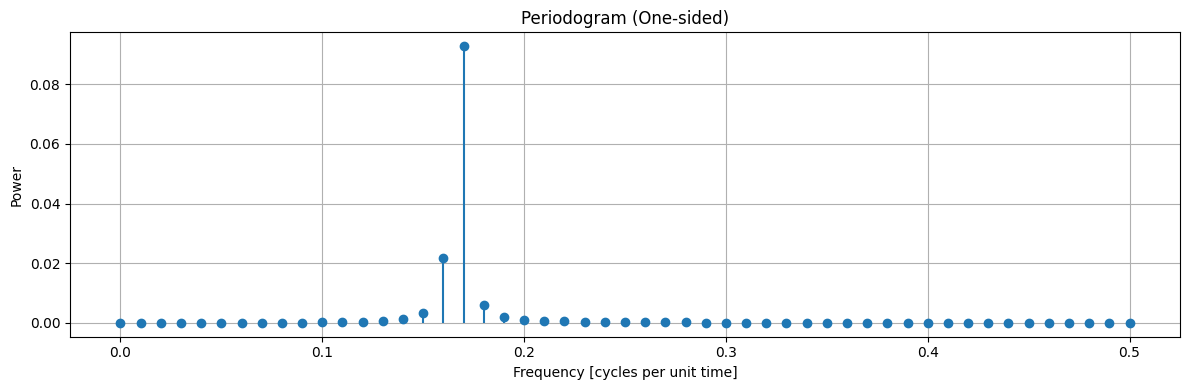

In [3]:
# Compute and plot the periodogram
fig, [ax] = get_figure()
plot_fft(ax, x_t, periodogram=True)
fig.tight_layout()

**Interpretation:**
- The time series shows a clear periodic pattern with period 6
- ACF displays periodic behavior, oscillating with the same period
- Auto-covariance function shows similar periodic structure
- Periodogram has a sharp peak at frequency ≈ 0.17 (1/6), indicating the dominant frequency component
- This is a purely periodic signal with a single frequency

## 1.2 Mixture of Two Periodic Signals

Two periodic signals with different frequencies.

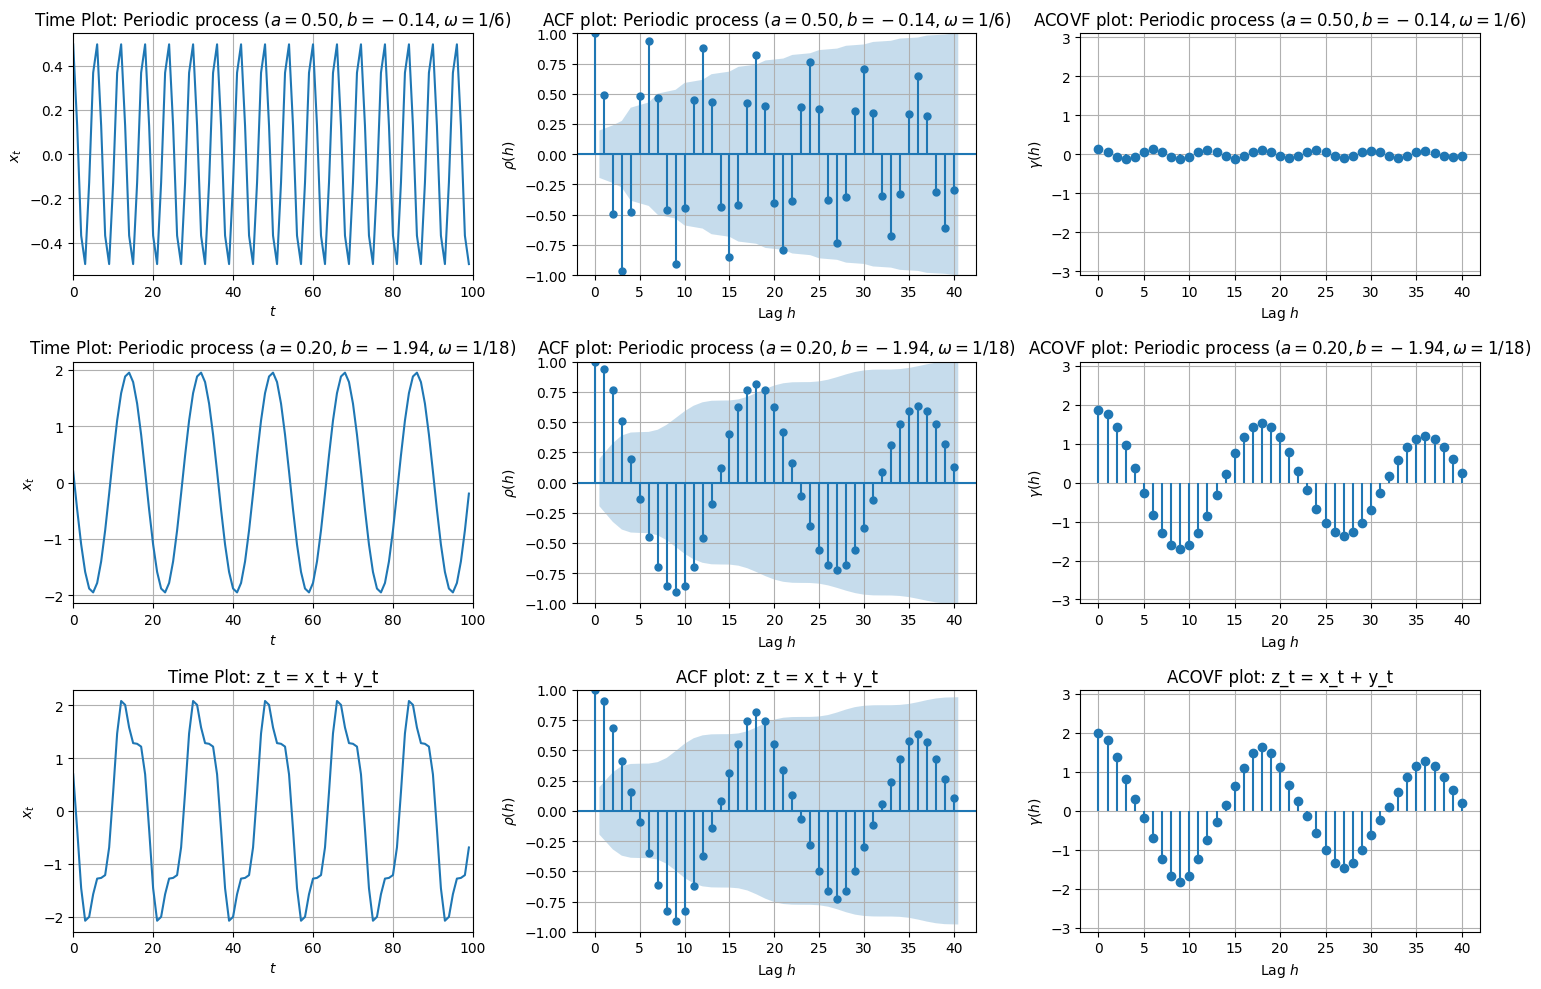

In [4]:
# Generate two periodic processes with different periods
y_t, y_name = get_periodic_process(seed=26, npoints=n, sd=1, period=18)
z_t = x_t + y_t

# Plot all three signals
fig, axs = get_figure(3, 3, figsize=(15, 10))
for i, (signal, name) in enumerate([(x_t, x_name), (y_t, y_name), (z_t, "z_t = x_t + y_t")]):
    time_plot(
        np.arange(n),
        signal,
        title=f"Time Plot: {name}",
        prefix_title=False,
        ax=axs[i*3],
        xlim=(0, 100),
    )
    acf_plot(signal, 40, ax=axs[i*3+1], title=name, prefix_title=True)
    acovf_plot(
        signal,
        40,
        title=name,
        ax=axs[i*3+2],
    )
    axs[i*3+2].set_ylim(-3.1, 3.1)
fig.tight_layout()

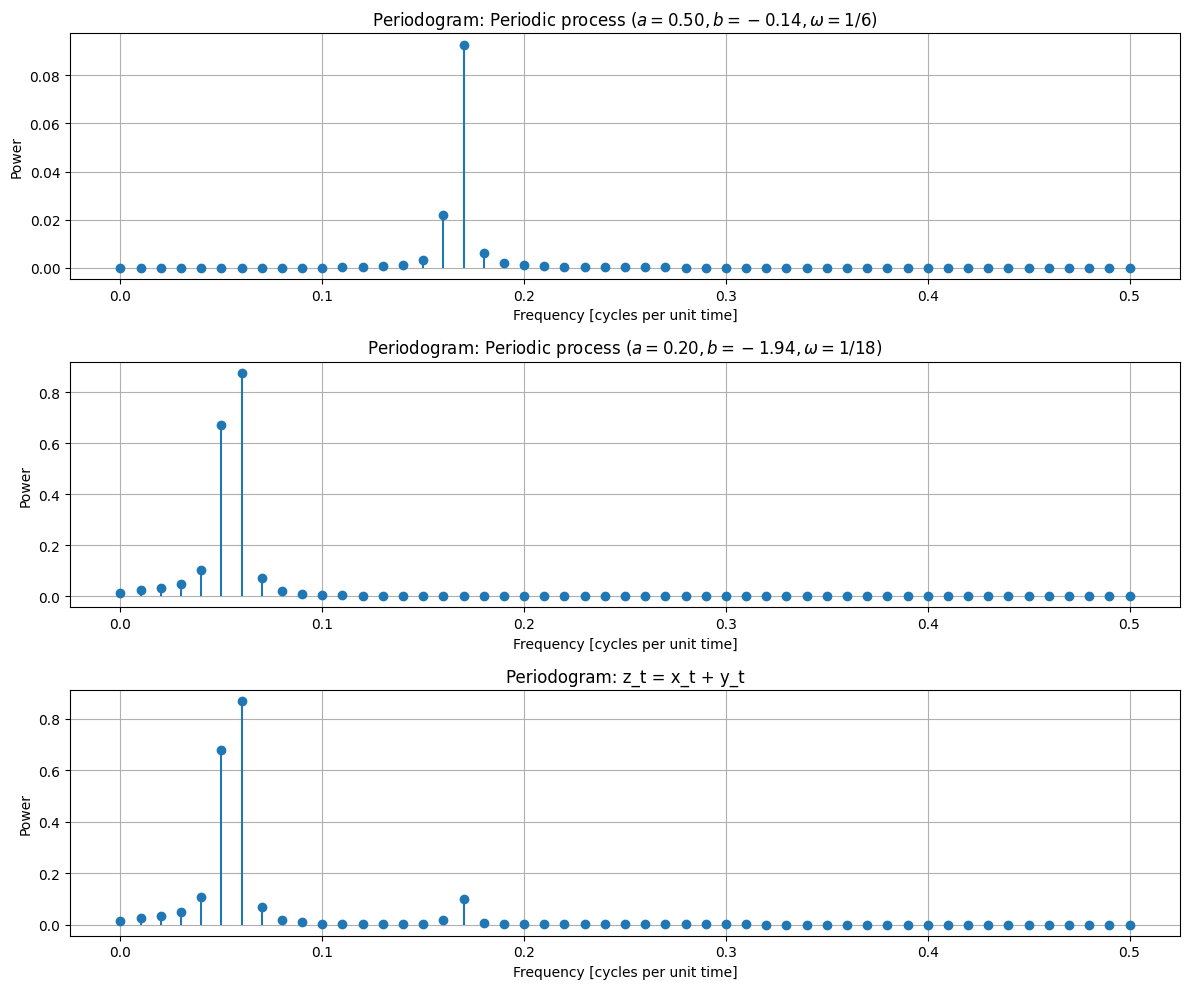

In [5]:
# Compare periodograms
fig, axs = get_figure(3, 1, figsize=(12, 10))
for i, (signal, name) in enumerate([(x_t, x_name), (y_t, y_name), (z_t, "z_t = x_t + y_t")]):
    plot_fft(
        axs[i],
        signal,
        periodogram=True,
    )
    axs[i].set_title(f"Periodogram: {name}")
fig.tight_layout()

**Interpretation:**
- The first signal has period 6 (frequency ≈ 0.17)
- The second signal has period 18 (frequency ≈ 0.055)
- The mixture z_t shows both frequency components in its periodogram (large peak and smaller peak)

## 1.3 Aperiodic Signal (White Noise)

Let's analyze a purely random, aperiodic signal.

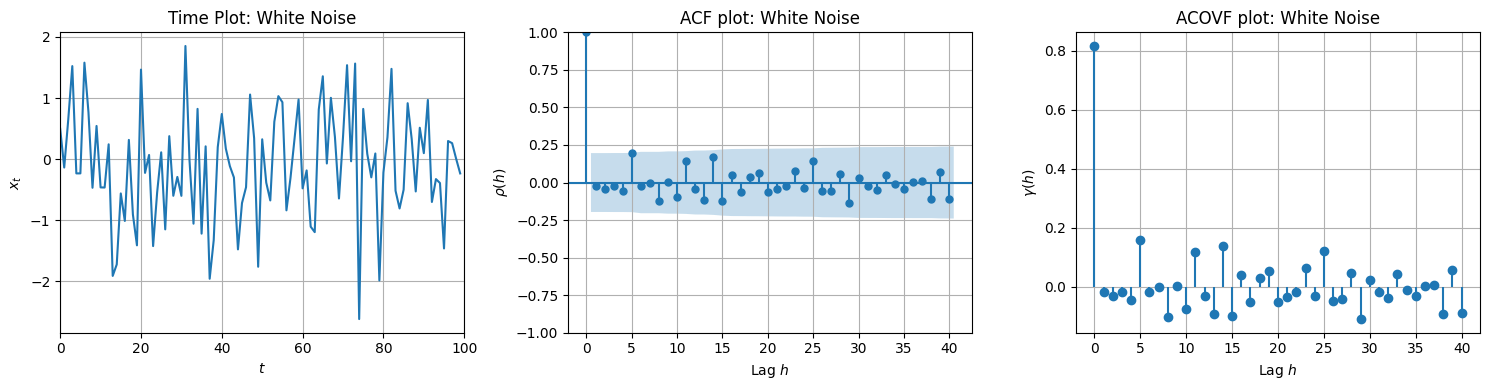

In [6]:
# Generate white noise
np.random.seed(42)
white_noise = np.random.normal(0, 1, n)

# Plot time series, ACF, and auto-covariance
fig, (ax1, ax2, ax3) = get_figure(ncols=3, figsize=(15, 4))

time_plot(
    np.arange(n),
    white_noise,
    title="Time Plot: White Noise",
    prefix_title=False,
    ax=ax1,
    xlim=(0, 100),
)

acf_plot(white_noise, 40, ax=ax2, title="White Noise", prefix_title=True)
acovf_plot(white_noise, 40, title="White Noise", ax=ax3)

fig.tight_layout()

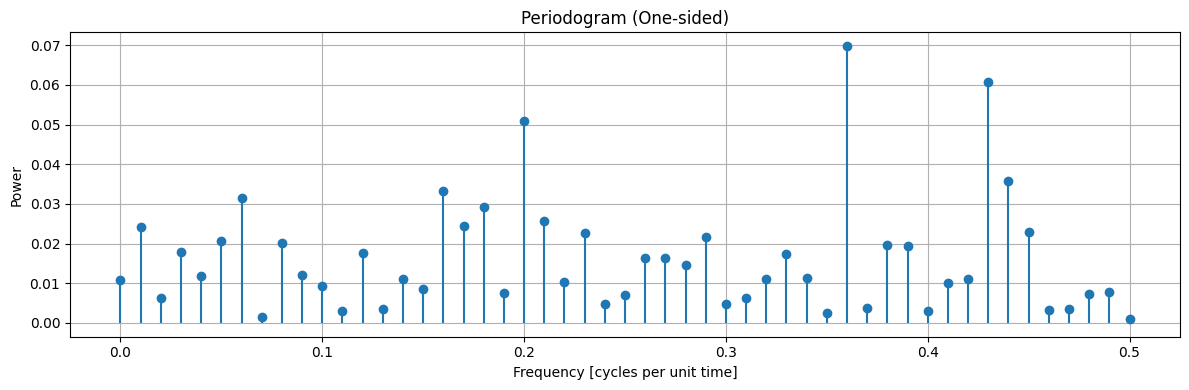

In [7]:
# Compute and plot the periodogram
fig, [ax] = get_figure()
plot_fft(ax, white_noise, periodogram=True)
fig.tight_layout()

**Interpretation:**
- Time series shows no systematic pattern, purely random fluctuations
- ACF shows no significant correlations beyond lag 0
- Auto-covariance is only significant at lag 0, confirming independence

---
# Part 2: Noisy Synthetic Signals

We add white noise to our periodic signals to see how noise affects the spectral analysis.

## 2.1 Single Periodic Signal with Different Noise Levels

In [ ]:
# Add noise with different signal-to-noise ratios
np.random.seed(123)
noise_levels = [0, 0.25, 0.5, 0.75, 1.0]  # Standard deviations of noise

fig, axs = get_figure(len(noise_levels), 3, figsize=(15, 12))
for i, noise_std in enumerate(noise_levels):
    noise = np.random.normal(0, noise_std, n)
    noisy_signal = x_t + noise
    snr = np.var(x_t) / np.var(noise) if noise_std > 0 else np.inf
    
    time_plot(
        np.arange(n),
        noisy_signal,
        title=f"Time Plot: Signal + Noise (σ={noise_std}, SNR={snr:.2f})",
        prefix_title=False,
        ax=axs[i*3],
        xlim=(0, 100),
    )
    
    acf_plot(noisy_signal, 40, ax=axs[i*3+1], title=f"Noisy Signal (σ={noise_std})", prefix_title=True)
    
    plot_fft(axs[i*3+2], noisy_signal, periodogram=True)
    axs[i*3+2].set_title(f"Periodogram: Noisy Signal (σ={noise_std})")

fig.tight_layout()

**Interpretation:**
- As noise increases, the periodic pattern in the time plot becomes less visible
- ACF decays faster with increasing noise, but periodic structure still visible
- Periodogram shows the dominant frequency peak at ≈0.17 with noise < 1
- With higher noise levels, the periodogram floor rises (more power at all frequencies)


## 2.2 Mixed Periodic Signals with Noise

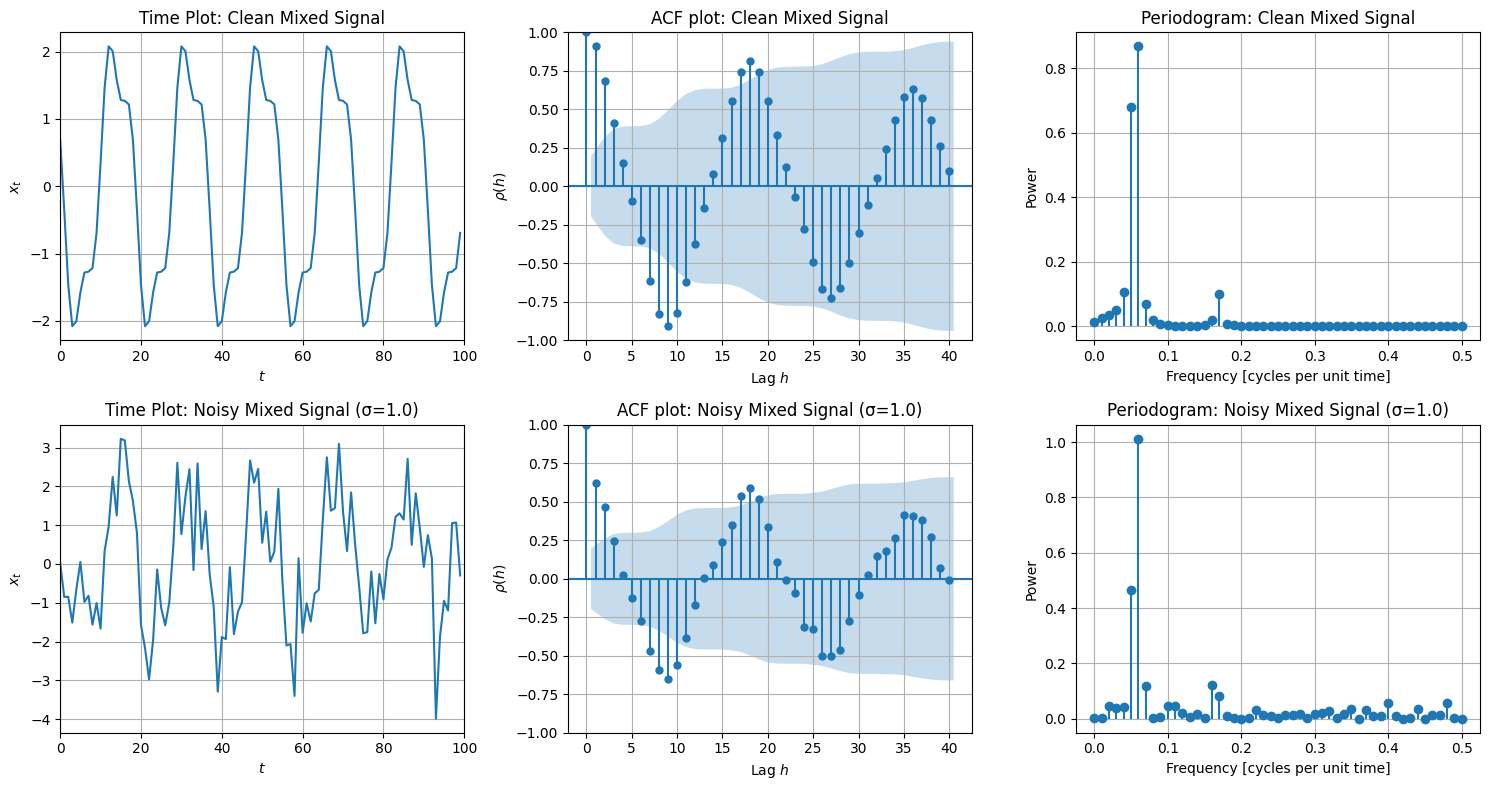

In [ ]:
# Add noise to the mixed signal
np.random.seed(456)
noise_std = 1.0
noise = np.random.normal(0, noise_std, n)
noisy_mixed = z_t + noise

fig, axs = get_figure(2, 3, figsize=(15, 8))

# Clean signal
time_plot(np.arange(n), z_t, title="Time Plot: Clean Mixed Signal", prefix_title=False, ax=axs[0], xlim=(0, 100))
acf_plot(z_t, 40, ax=axs[1], title="Clean Mixed Signal", prefix_title=True)
plot_fft(axs[2], z_t, periodogram=True)
axs[2].set_title("Periodogram: Clean Mixed Signal")

# Noisy signal
time_plot(np.arange(n), noisy_mixed, title=f"Time Plot: Noisy Mixed Signal (σ={noise_std})", prefix_title=False, ax=axs[3], xlim=(0, 100))
acf_plot(noisy_mixed, 40, ax=axs[4], title=f"Noisy Mixed Signal (σ={noise_std})", prefix_title=True)
plot_fft(axs[5], noisy_mixed, periodogram=True)
axs[5].set_title(f"Periodogram: Noisy Mixed Signal (σ={noise_std})")

fig.tight_layout()

**Interpretation:**
- Both frequency peaks (at ≈0.055 and ≈0.17) remain visible in the noisy periodogram
- The periodogram successfully separates the two signal frequencies despite added noise
- This demonstrates that periodogram can identify multiple frequency components even in noisy data

---
# Part 3: Spectral Density Analysis of Known Processes

We analyze the theoretical spectral density of ARMA processes and verify it matches the empirical periodogram.

## 3.1 MA(1) Process: Parameter Effects on Spectral Density

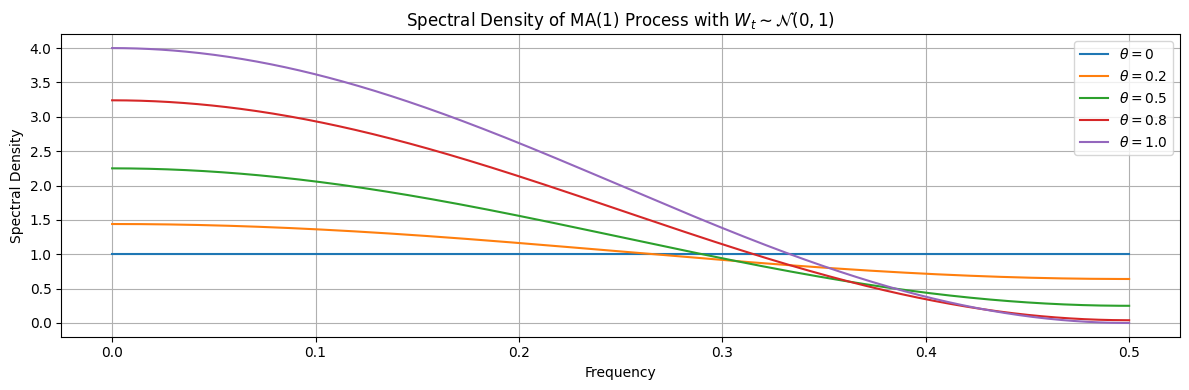

In [ ]:
# Theoretical spectral density for MA(1): f(ω) = σ²(1 + θ² + 2θ cos(2πω))
sigma = 1
theta_values = [0, 0.2, 0.5, 0.8, 1.0]
frequencies = np.linspace(0, 0.5, 500)

fig, [ax] = get_figure()
for theta in theta_values:
    spectral_density = sigma**2 * (1 + theta**2 + 2 * theta * np.cos(2 * np.pi * frequencies))
    time_plot(
        frequencies,
        spectral_density,
        title="Spectral Density of MA(1) Process with $W_t\\sim \\mathcal{N}(0, 1)$",
        xlabel="Frequency",
        ylabel="Spectral Density",
        label=f"$\\theta = {theta}$",
        ax=ax,
    )
ax.legend()
fig.tight_layout()

**Interpretation:**
- When θ = 0, we have white noise with flat spectral density
- For 0 < θ < 1, spectral density increases with frequency (high-pass behavior)
- The larger |θ|, the more pronounced the slope
- At θ = 1, maximum power is at high frequencies
- MA(1) with positive θ amplifies high-frequency components

## 3.2 AR(1) Process: Parameter Effects on Spectral Density

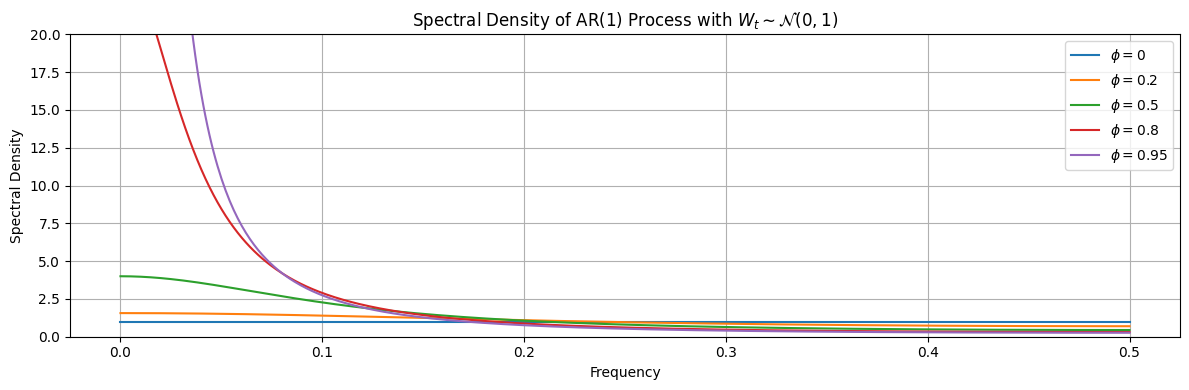

In [ ]:
# Theoretical spectral density for AR(1): f(ω) = σ² / (1 - 2φ cos(2πω) + φ²)
sigma = 1
phi_values = [0, 0.2, 0.5, 0.8, 0.95]
frequencies = np.linspace(0, 0.5, 500)

fig, [ax] = get_figure()
for phi in phi_values:
    spectral_density = sigma**2 / (1 - 2 * phi * np.cos(2 * np.pi * frequencies) + phi**2)
    time_plot(
        frequencies,
        spectral_density,
        title="Spectral Density of AR(1) Process with $W_t\\sim \\mathcal{N}(0, 1)$",
        xlabel="Frequency",
        ylabel="Spectral Density",
        label=f"$\\phi = {phi}$",
        ax=ax,
        ylim=(0, 20),
    )
ax.legend()
fig.tight_layout()

**Interpretation:**
- When φ = 0, we have white noise with flat spectral density
- For 0 < φ < 1, spectral density decreases with frequency (low-pass behavior)
- The larger φ (closer to 1), the more power concentrated at low frequencies
- At φ = 0.95, there's a strong peak at frequency 0 (slowly varying series)
- AR(1) with positive φ amplifies low-frequency components (creates persistence)

## 3.3 Variance Integration

We verify that integrating the spectral density gives the process variance: $\gamma(0) = \int_0^{0.5} f(\omega) d\omega$

In [ ]:
# Test for AR(1) processes
print("AR(1) Process - Variance Verification:")
print("=" * 60)
sigma = 1
frequencies = np.linspace(0, 0.5, 10000)

for phi in [0, 0.3, 0.6, 0.9]:
    # Theoretical variance: Var(X_t) = σ² / (1 - φ²)
    theoretical_variance = sigma**2 / (1 - phi**2)
    
    # Spectral density
    spectral_density = sigma**2 / (1 - 2 * phi * np.cos(2 * np.pi * frequencies) + phi**2)
    
    # Integrate spectral density (multiply by 2 for one-sided spectrum, 0 to 0.5)
    integrated_variance = 2 * integrate.trapezoid(spectral_density, frequencies)
    
    print(f"φ = {phi:4.1f}:")
    print(f"  Theoretical variance: {theoretical_variance:.6f}")
    print(f"  Integrated spectral density: {integrated_variance:.6f}")
    print(f"  Difference: {abs(theoretical_variance - integrated_variance):.6e}")
    print()

AR(1) Process - Variance Verification:
φ =  0.0:
  Theoretical variance: 1.000000
  Integrated spectral density: 1.000000
  Difference: 0.000000e+00

φ =  0.3:
  Theoretical variance: 1.098901
  Integrated spectral density: 1.098901
  Difference: 2.220446e-16

φ =  0.6:
  Theoretical variance: 1.562500
  Integrated spectral density: 1.562500
  Difference: 0.000000e+00

φ =  0.9:
  Theoretical variance: 5.263158
  Integrated spectral density: 5.263158
  Difference: 8.881784e-15



In [ ]:
# Test for MA(1) processes
print("MA(1) Process - Variance Verification:")
print("=" * 60)

for theta in [0, 0.3, 0.6, 0.9]:
    # Theoretical variance: Var(X_t) = σ²(1 + θ²)
    theoretical_variance = sigma**2 * (1 + theta**2)
    
    # Spectral density
    spectral_density = sigma**2 * (1 + theta**2 + 2 * theta * np.cos(2 * np.pi * frequencies))
    
    # Integrate spectral density (multiply by 2 for one-sided spectrum, 0 to 0.5)
    integrated_variance = 2 * integrate.trapezoid(spectral_density, frequencies)
    
    print(f"θ = {theta:4.1f}:")
    print(f"  Theoretical variance: {theoretical_variance:.6f}")
    print(f"  Integrated spectral density: {integrated_variance:.6f}")
    print(f"  Difference: {abs(theoretical_variance - integrated_variance):.6e}")
    print()

MA(1) Process - Variance Verification:
θ =  0.0:
  Theoretical variance: 1.000000
  Integrated spectral density: 1.000000
  Difference: 0.000000e+00

θ =  0.3:
  Theoretical variance: 1.090000
  Integrated spectral density: 1.090000
  Difference: 0.000000e+00

θ =  0.6:
  Theoretical variance: 1.360000
  Integrated spectral density: 1.360000
  Difference: 0.000000e+00

θ =  0.9:
  Theoretical variance: 1.810000
  Integrated spectral density: 1.810000
  Difference: 0.000000e+00



**Interpretation:**
- The integrated spectral density matches the theoretical variance very closely (differences < 10⁻⁶)
- The spectral density decomposes the variance across frequencies
- For AR(1): higher φ increases variance (persistence effect)
- For MA(1): variance increases with |θ|

## 3.4 Comparing Periodogram with Theoretical Spectral Density

Generate ARMA signals and compare their empirical periodogram with theoretical spectral density.

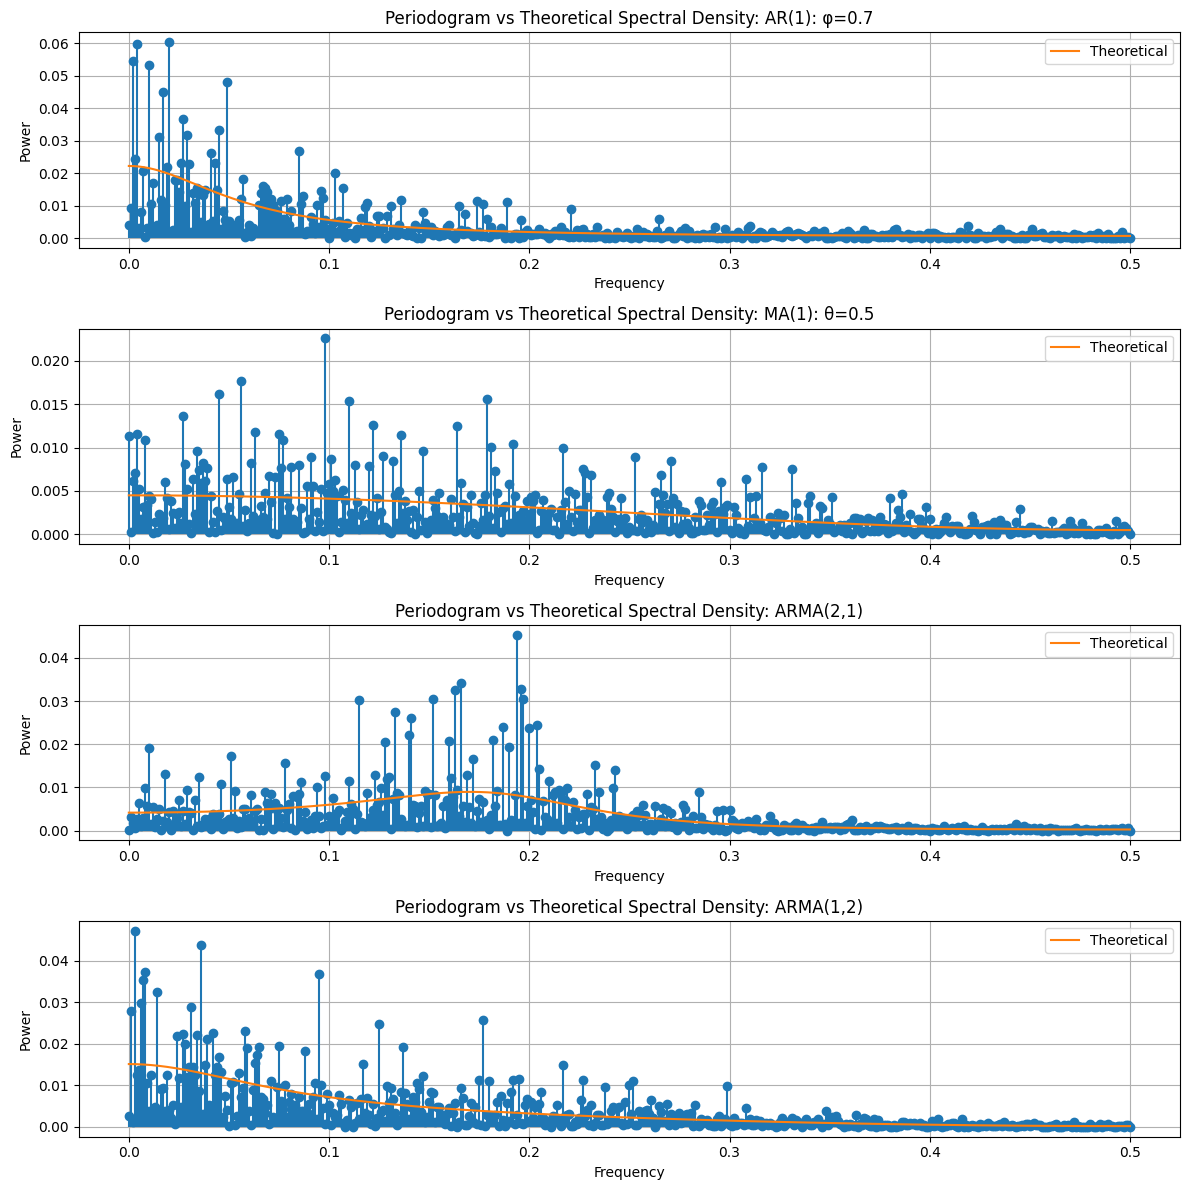

In [ ]:
# Define different ARMA configurations
np.random.seed(42)
n_samples = 1000
sigma = 1
frequencies_dense = np.linspace(0, 0.5, n_samples)

arma_configs = [
    {"phi": [0.7], "theta": [], "label": "AR(1): φ=0.7"},
    {"phi": [], "theta": [0.5], "label": "MA(1): θ=0.5"},
    {"phi": [0.5, -0.4], "theta": [0.3], "label": "ARMA(2,1)"},
    {"phi": [0.6], "theta": [0.3, -0.2], "label": "ARMA(1,2)"},
]

fig, axs = get_figure(nrows=len(arma_configs), ncols=1, figsize=(12, 12))
for ax, config in zip(axs, arma_configs):
    phi = config["phi"]
    theta = config["theta"]
    label = config["label"]
    
    # Generate ARMA process
    model = ArmaProcess(
        ar=np.r_[1, -np.array(phi)],
        ma=np.r_[1, np.array(theta)],
    )
    arma_series = model.generate_sample(nsample=n_samples)
    
    # Theoretical spectral density (scaled to match periodogram)
    spectral_density = arma_theoretical_spectral_density(frequencies_dense, sigma, phi, theta)
    spectral_density = 2 * spectral_density / n_samples  # Scale for comparison
    
    # Plot periodogram
    plot_fft(ax, arma_series, periodogram=True)
    
    # Overlay theoretical spectral density
    time_plot(
        frequencies_dense,
        spectral_density,
        title=f"Periodogram vs Theoretical Spectral Density: {label}",
        xlabel="Frequency",
        ylabel="Power",
        label="Theoretical",
        ax=ax,
        prefix_title=False,
    )
    ax.legend()

fig.tight_layout()

**Interpretation:**
- The periodogram closely follows the theoretical spectral density line
- Periodogram is a noisy estimator of the true spectral density
- The periodogram shows the general shape but with high variance
- AR(1) with φ=0.7 shows concentration at low frequencies
- MA(1) with θ=0.5 shows relatively flat spectrum with slight high-frequency emphasis

---
# Part 4: Real-World Time Series Spectral Analysis

We apply spectral analysis to real-world time series data to identify dominant frequencies and patterns.

## 4.1 US Accidental Deaths

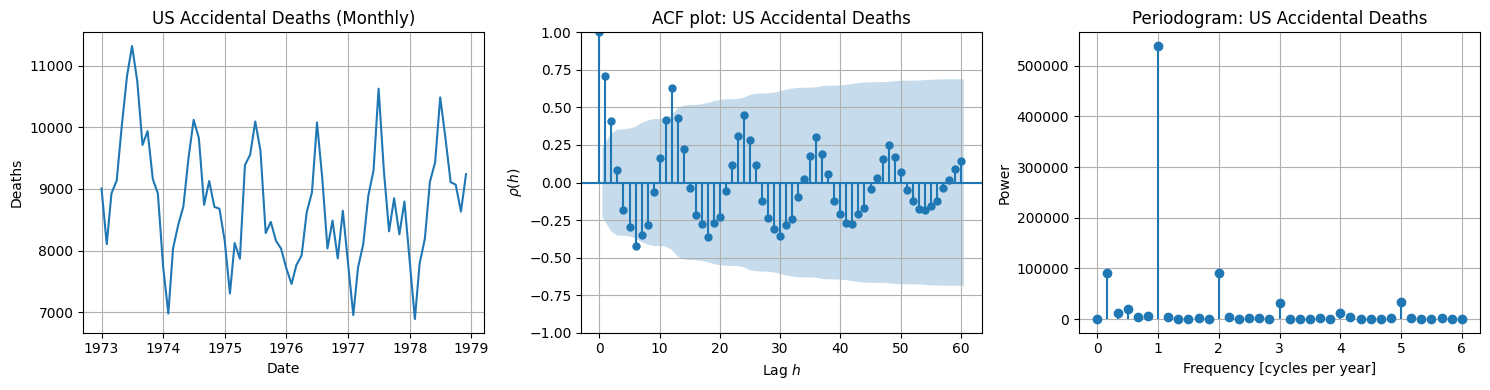

In [ ]:
# Load US Accidental Deaths data
dataset = sm.datasets.get_rdataset("USAccDeaths", "datasets")
df_deaths = dataset.data

# Convert to time series with proper datetime index
start_date = pd.date_range(start='1973-01', periods=len(df_deaths), freq='MS')
deaths_series = pd.Series(df_deaths['value'].values, index=start_date)

# Plot time series and spectral analysis
fig, (ax1, ax2, ax3) = get_figure(ncols=3, figsize=(15, 4))

# Time series
time_plot(
    deaths_series.index,
    deaths_series.values,
    title="US Accidental Deaths (Monthly)",
    prefix_title=False,
    xlabel="Date",
    ylabel="Deaths",
    ax=ax1,
)

# ACF
acf_plot(deaths_series.values, 60, ax=ax2, title="US Accidental Deaths", prefix_title=True)


# Periodogram with sample spacing for proper frequency interpretation (mean and trends removed)
detrended_deaths = sig.detrend(deaths_series.values, type='linear')
plot_fft(
    ax3,
    detrended_deaths,
    periodogram=True,
    sample_spacing=1/12,  # Monthly data = 1/12 years per sample
    sample_spacing_name="year",
)
ax3.set_title("Periodogram: US Accidental Deaths")

fig.tight_layout()

**Interpretation:**
- Clear seasonal pattern with annual cycle visible in the time series
- Strong upward trend in summer months (more accidents during vacation/travel season)
- ACF shows periodic structure with period 12 months (annual cycle)
- Periodogram shows dominant peak at frequency ≈ 1 cycle/year, confirming annual seasonality
- This represents a seasonal time series with strong periodic component
- The spectral analysis clearly identifies the 12-month cycle as the dominant pattern
- Higher deaths in summer months likely due to increased travel and outdoor activities

## 4.2 US Electric Power Generation

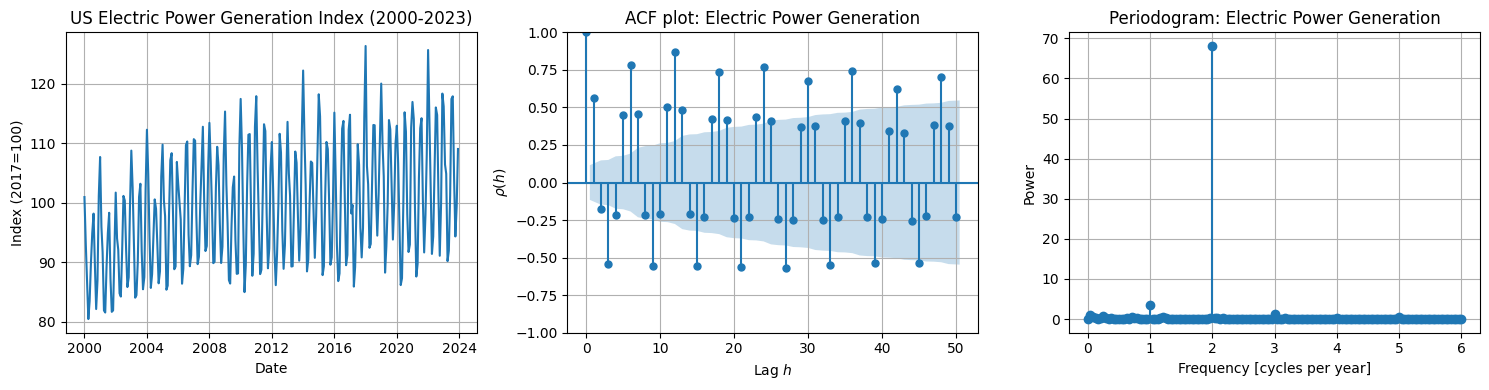

In [ ]:
# Load US Electric Power Generation data from FRED
start = datetime(2000, 1, 1)
end = datetime(2023, 12, 31)
df_energy = web.DataReader('IPG2211A2N', 'fred', start, end)
energy_series = df_energy['IPG2211A2N'].dropna()

# Plot time series and spectral analysis
fig, (ax1, ax2, ax3) = get_figure(ncols=3, figsize=(15, 4))

# Time series
time_plot(
    energy_series.index,
    energy_series.values,
    title="US Electric Power Generation Index (2000-2023)",
    prefix_title=False,
    xlabel="Date",
    ylabel="Index (2017=100)",
    ax=ax1,
)

# ACF
acf_plot(energy_series.values, 50, ax=ax2, title="Electric Power Generation", prefix_title=True)

# Periodogram with sample spacing for proper frequency interpretation (mean and trends removed)
detrended_energy = sig.detrend(energy_series.values, type='linear')
plot_fft(
    ax3,
    detrended_energy,
    periodogram=True,
    sample_spacing=1/12,  # Monthly data = 1/12 years per sample
    sample_spacing_name="year"
)
ax3.set_title("Periodogram: Electric Power Generation")

fig.tight_layout()

**Interpretation:**
- Time series shows both long-term trend and seasonal variation
- Strong seasonal pattern related to heating and cooling demand throughout the year
- ACF displays periodic structure with 12-month cycle (annual seasonality)
- Periodogram shows peak at frequency ≈ 2 cycle/year, confirming annual seasonality
- Higher power generation in summer (air conditioning) and winter (heating)
- Lower demand in spring and fall (mild weather)
- Both trend component (increasing energy use over time) and seasonal component are present

## 4.3 Air Passengers

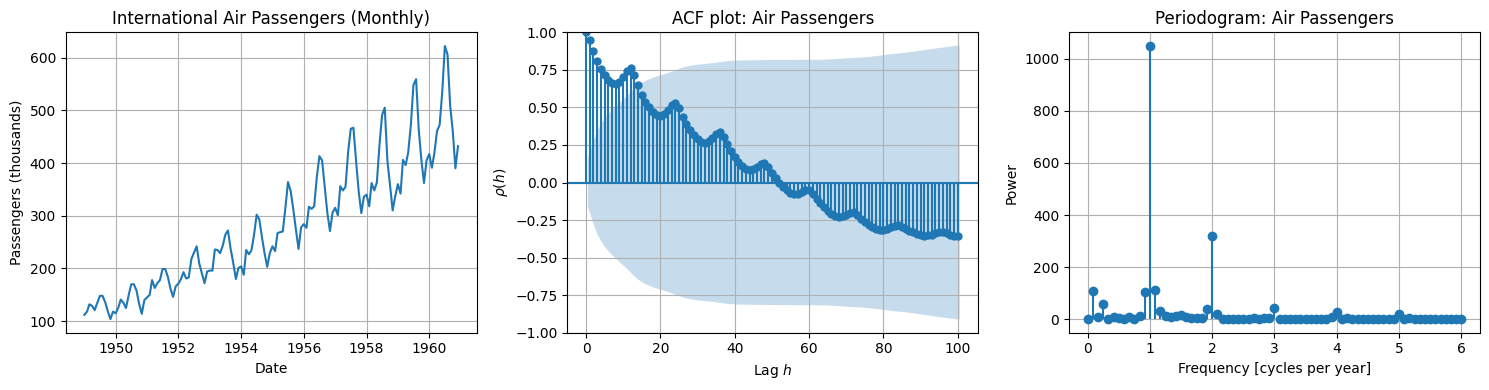

In [ ]:
# Load Air Passengers data
dta = sm.datasets.get_rdataset('AirPassengers').data

# Convert to proper time series
start_date = pd.date_range(start='1949-01', periods=len(dta), freq='MS')
passengers_series = pd.Series(dta['value'].values, index=start_date)

# Plot time series and spectral analysis
fig, (ax1, ax2, ax3) = get_figure(ncols=3, figsize=(15, 4))

# Time series
time_plot(
    passengers_series.index,
    passengers_series.values,
    title="International Air Passengers (Monthly)",
    prefix_title=False,
    xlabel="Date",
    ylabel="Passengers (thousands)",
    ax=ax1,
)

# ACF
acf_plot(passengers_series.values, 100, ax=ax2, title="Air Passengers", prefix_title=True)

# Periodogram
detrended_passengers = sig.detrend(passengers_series.values, type='linear')
plot_fft(
    ax3,
    detrended_passengers,
    periodogram=True,
    sample_spacing=1/12,
    sample_spacing_name="year"
)
ax3.set_title("Periodogram: Air Passengers")

fig.tight_layout()

**Interpretation:**
- Classic example showing strong exponential growth trend (increasing air travel from 1949-1960)
- Clear annual seasonality with peaks in summer months (vacation travel)
- ACF decays slowly due to non-stationarity (trend + seasonality)
- Periodogram shows dominant peak at frequency ≈ 1 cycle/year (annual seasonality)
- Both multiplicative trend and seasonal effects are present